---
title: "Lecture 6: Continuous Random Variables, PDFs, CDFs"
author: "Jamie Haddock"
format:
    revealjs:
        output-file: Lecture6_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
        html-math-method: katex
    html:
        code-fold: true
        embed-resources: true
        output-file: Lecture6
        code-links:
          - text: "Open in Colab"
            href: "https://colab.research.google.com/github/jamiehadd/Math-151-Probability/blob/main/06_continuous-random-variables-pdfs-cdfs.ipynb"
            icon: "laptop"
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        output-file: Lecture6
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: python3
colab:
  gh-user: "jamiehadd"
  gh-repo: "Math-151-Probability"
filters:
  - input/remove-pause.lua
  - colab
execute:
  echo: true
  eval: true
---

## Why do we need a new kind of random variable?

Every random variable so far has been **discrete**: a finite or countably infinite
list of possible values, each with its own probability mass. But plenty of quantities
we'd like to model — a waiting time, a position, a measurement error — can take *any*
real value in an interval. There's no way to list them out one at a time.

::: {.callout-note}
## Definition: Continuous random variable, PDF
A random variable $X$ is **continuous** if there is a function $f_X(x)\ge 0$, called
its **probability density function (PDF)**, such that for every interval $[a,b]$,
$$
P(a \le X \le b) = \int_a^b f_X(x)\, dx, \qquad \int_{-\infty}^{\infty} f_X(x)\,dx = 1.
$$
:::

Instead of bars of probability sitting on individual points (a PMF), probability is
now **area under a curve**.

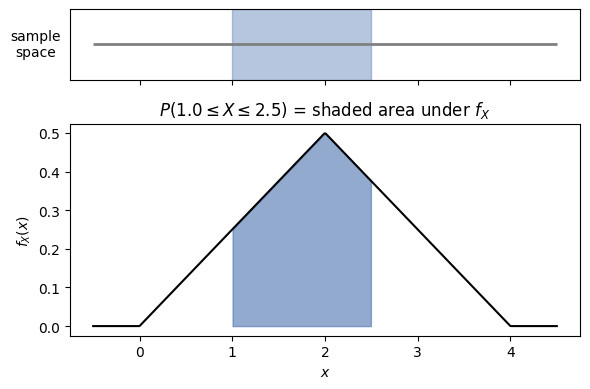

total area under f_X (should be 1): 1.0000
shaded area P(1.0<=X<=2.5):         0.5938


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

def f_generic(t):
    t = np.asarray(t, dtype=float)
    return np.where((t >= 0) & (t <= 2), t / 4, np.where((t > 2) & (t <= 4), (4 - t) / 4, 0.0))

xs = np.linspace(-0.5, 4.5, 400)
a, b = 1.0, 2.5

fig, axes = plt.subplots(2, 1, figsize=(6, 4), sharex=True,
                          gridspec_kw={'height_ratios': [1, 3]})

# top: the sample space itself -- a continuum of outcomes
axes[0].hlines(0, -0.5, 4.5, color='gray', lw=2)
axes[0].axvspan(a, b, color='#4C72B0', alpha=0.4)
axes[0].set_yticks([])
axes[0].set_ylabel('sample\nspace', rotation=0, labelpad=25, va='center')

# bottom: the PDF, same shaded interval
axes[1].plot(xs, f_generic(xs), color='black')
mask = (xs >= a) & (xs <= b)
axes[1].fill_between(xs[mask], f_generic(xs[mask]), color='#4C72B0', alpha=0.6)
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$f_X(x)$')
axes[1].set_title(f'$P({a} \\leq X \\leq {b})$ = shaded area under $f_X$')

plt.tight_layout()
plt.show()

total_area, _ = quad(f_generic, -1, 5)
shaded_area, _ = quad(f_generic, a, b)
print(f"total area under f_X (should be 1): {total_area:.4f}")
print(f"shaded area P({a}<=X<={b}):         {shaded_area:.4f}")

## Example: the continuous uniform random variable

::: {.callout-note}
## Definition: Uniform($a,b$)
$$
f_X(x) = \begin{cases}\dfrac{1}{b-a} & a\le x\le b\\[4pt] 0 & \text{otherwise.}\end{cases}
$$
:::

Every value in $[a,b]$ is "equally likely," in the sense that the density is flat —
probability of a sub-interval depends only on its *length*, not its location.

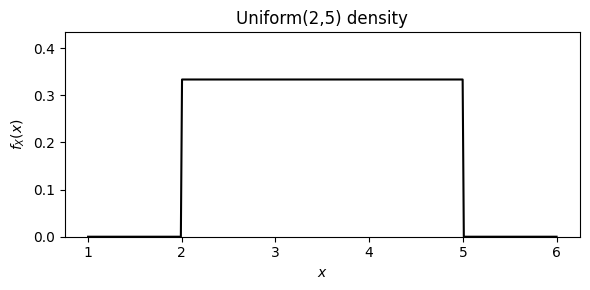

total area:        1.0000
P(3 <= X <= 4) =   0.3333   (should be 1/3 = 0.3333, since [3,4] is 1/3 of [2,5])


In [2]:
a_u, b_u = 2, 5

def f_uniform(x):
    x = np.asarray(x, dtype=float)
    return np.where((x >= a_u) & (x <= b_u), 1 / (b_u - a_u), 0.0)

xs = np.linspace(a_u - 1, b_u + 1, 400)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(xs, f_uniform(xs), color='black')
ax.set_ylim(0, 1 / (b_u - a_u) * 1.3)
ax.set_xlabel('$x$')
ax.set_ylabel('$f_X(x)$')
ax.set_title(f'Uniform({a_u},{b_u}) density')
plt.tight_layout()
plt.show()

total, _ = quad(f_uniform, a_u - 1, b_u + 1)
p_3_4, _ = quad(f_uniform, 3, 4)
print(f"total area:        {total:.4f}")
print(f"P(3 <= X <= 4) =   {p_3_4:.4f}   (should be 1/3 = {1/3:.4f}, since [3,4] is 1/3 of [2,5])")

## Example: a PDF can take arbitrarily large values

::: {.callout-warning}
## A density is *not* a probability
Nothing in the definition requires $f_X(x)\le 1$ — only that the *total area* equals
$1$. Squeeze the same unit of probability into a short enough interval and the height
of the density can be as large as you like.
:::

A consequence worth stating on its own:

::: {.callout-note}
## Fact: $P(X=x_0)=0$ for continuous $X$
For any single point $x_0$,
$$
P(X=x_0) = \int_{x_0}^{x_0} f_X(x)\,dx = 0,
$$
since we're integrating over an interval of zero width. Continuous random variables
put *no* probability mass on individual points — only on intervals of positive
length.
:::

## Expectation of a continuous random variable

::: {.callout-note}
## Definition: Expectation
$$
E[X] = \int_{-\infty}^{\infty} x\, f_X(x)\, dx.
$$
:::

::: {.callout-note}
## Theorem: LOTUS for continuous random variables
For any function $g$,
$$
E[g(X)] = \int_{-\infty}^{\infty} g(x)\, f_X(x)\, dx.
$$
:::

::: {.callout-note}
## Definitions: moments and variance
The $k$-th **moment** of $X$ is $E[X^k]$. **Variance** is defined exactly as in the
discrete case,
$$
\mathrm{Var}(X) = E\big[(X-E[X])^2\big] = E[X^2]-(E[X])^2,
$$
and the shortcut formula's proof (L4) used only linearity — nothing about summing
versus integrating — so it carries over unchanged.
:::

::: {.callout-caution}
## In-class exercise
Prove that for constants $a,b$ and a continuous random variable $X$:
$$
E[aX+b] = aE[X]+b \qquad\text{and}\qquad \mathrm{Var}(aX+b) = a^2\,\mathrm{Var}(X).
$$
:::

**Solution:** identical to L4's discrete proof, with sums replaced by integrals.
$$
E[aX+b] = \int (ax+b)\, f_X(x)\,dx = a\int x\, f_X(x)\,dx + b\int f_X(x)\,dx = aE[X]+b.
$$
$$
\mathrm{Var}(aX+b) = E\big[(aX+b-aE[X]-b)^2\big] = E\big[a^2(X-E[X])^2\big] = a^2\,\mathrm{Var}(X).
$$

Neither proof ever used discreteness or continuity — only linearity of the sum (or
integral). Every fact about expectation and variance built on linearity in L4 carries
over to continuous RVs with zero extra work.

## The Exponential random variable

The continuous "cousin" of the Geometric — instead of counting *trials* until an
event, it measures the *waiting time* until an event that can happen at any instant.

::: {.callout-note}
## Definition: Exponential($\lambda$)
$$
f_X(x) = \begin{cases}\lambda e^{-\lambda x} & x \ge 0\\ 0 & x<0,\end{cases}
\qquad \lambda>0.
$$
:::

. . .

$$
E[X] = \frac1\lambda, \qquad \mathrm{Var}(X) = \frac1{\lambda^2}
$$
(both derivable by integration by parts) — the same shape of answer as the
Geometric($p$) mean $1/p$ from L3, with $\lambda$ playing the role of a *continuous
rate* in place of $p$.

**Example:** customers arrive at a coffee shop at an average rate of $\lambda=3$ per
hour, memorylessly (the time since the last arrival tells you nothing about when the
next one comes). The waiting time $X$ until the next customer is Exponential($3$),
measured in hours, so $E[X]=\tfrac13$ hour $=20$ minutes.

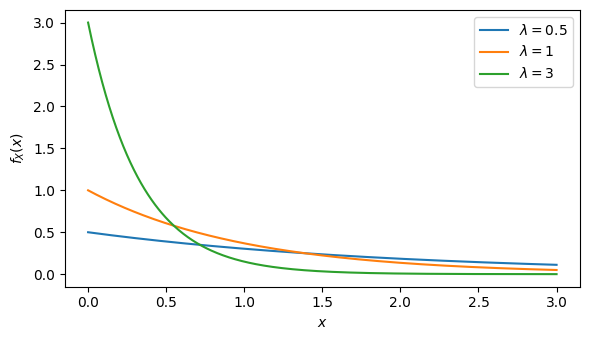

lambda = 3.0
E[X]:   formula 1/lambda   = 0.3333   quad = 0.3333   simulated = 0.3327
Var(X): formula 1/lambda^2 = 0.1111   quad = 0.1111   simulated = 0.1112


In [6]:
def f_exp(x, lam):
    x = np.asarray(x, dtype=float)
    return np.where(x >= 0, lam * np.exp(-lam * x), 0.0)

xs = np.linspace(0, 3, 400)
fig, ax = plt.subplots(figsize=(6, 3.5))
for lam in [0.5, 1, 3]:
    ax.plot(xs, f_exp(xs, lam), label=f'$\\lambda={lam}$')
ax.set_xlabel('$x$')
ax.set_ylabel('$f_X(x)$')
ax.legend()
plt.tight_layout()
plt.show()

lam = 3.0  # the coffee shop: 3 customers/hour
E_exp_num, _ = quad(lambda x: x * f_exp(x, lam), 0, 50)
E_exp2_num, _ = quad(lambda x: x ** 2 * f_exp(x, lam), 0, 50)
Var_exp_num = E_exp2_num - E_exp_num ** 2

rng = np.random.default_rng(151)
wait_times = rng.exponential(1 / lam, size=1_000_000)  # numpy's scale parameter is 1/lambda

print(f"lambda = {lam}")
print(f"E[X]:   formula 1/lambda   = {1/lam:.4f}   quad = {E_exp_num:.4f}   simulated = {wait_times.mean():.4f}")
print(f"Var(X): formula 1/lambda^2 = {1/lam**2:.4f}   quad = {Var_exp_num:.4f}   simulated = {wait_times.var():.4f}")

## Cumulative Distribution Functions

::: {.callout-note}
## Definition: CDF
For *any* random variable $X$ — discrete or continuous —
$$
F_X(x) = P(X \le x).
$$
:::

Unlike the PMF or PDF, the CDF is defined the *same way* regardless of type. And each
of PMF, PDF, or CDF — whichever applies to $X$ — **unambiguously pins down the entire
distribution**: from any one of them, you can recover the others.

## Properties of the CDF

Every CDF, discrete or continuous, satisfies:

- **monotonically nondecreasing:** $x_1 \le x_2 \implies F_X(x_1)\le F_X(x_2)$,
- $F_X(x) \to 0$ as $x\to-\infty$, and $F_X(x)\to 1$ as $x\to\infty$,
- for **discrete** $X$: $F_X$ is a **piecewise-constant step function** — flat except
  for a jump of size $p_X(x)$ at every $x$ in the range of $X$,
- for **continuous** $X$: $F_X$ is **continuous** everywhere (no jumps at all —
  consistent with $P(X=x_0)=0$ for every $x_0$).

. . .

**Relation between PDF and CDF, for $X$ continuous:**
$$
F_X(x) = \int_{-\infty}^x f_X(t)\,dt, \qquad\text{equivalently}\qquad f_X(x) = F_X'(x)
$$
wherever $F_X$ is differentiable — the Fundamental Theorem of Calculus, moonlighting
as a probability fact.

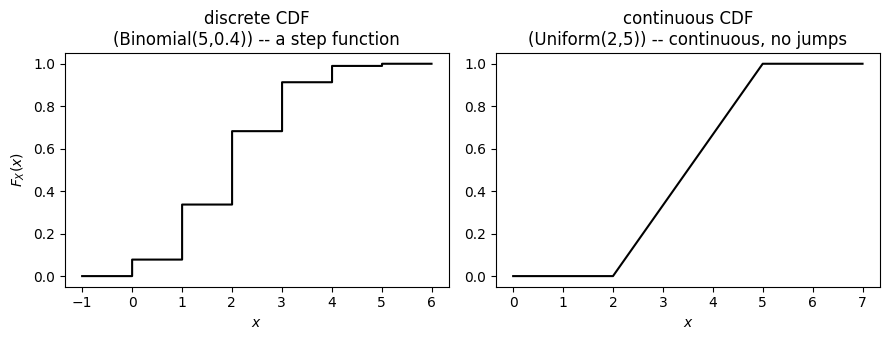

In [7]:
from scipy.stats import binom

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

# discrete: Binomial(5, 0.4) CDF -- a step function
n_b, p_b = 5, 0.4
xs_d = np.linspace(-1, 6, 700)
cdf_d = binom.cdf(np.floor(xs_d), n_b, p_b)
axes[0].step(xs_d, cdf_d, where='post', color='black')
axes[0].set_title('discrete CDF\n(Binomial(5,0.4)) -- a step function')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$F_X(x)$')

# continuous: Uniform(2,5) CDF -- continuous, and (in this special case) piecewise linear
xs_c = np.linspace(0, 7, 400)
cdf_c = np.clip((xs_c - a_u) / (b_u - a_u), 0, 1)
axes[1].plot(xs_c, cdf_c, color='black')
axes[1].set_title('continuous CDF\n(Uniform(2,5)) -- continuous, no jumps')
axes[1].set_xlabel('$x$')

plt.tight_layout()
plt.show()

## Geometric and Exponential CDFs

$$
X\sim\text{Geometric}(p): \quad F_X(k) = 1-(1-p)^k, \qquad k=1,2,\dots
$$
$$
X\sim\text{Exponential}(\lambda): \quad F_X(x) = 1-e^{-\lambda x}, \qquad x\ge 0.
$$

. . .

Same shape of formula — because the Exponential really is the **continuous limit**
of the Geometric. Chop a unit of time into $n$ tiny slices, let each slice
independently "succeed" with probability $p=\lambda/n$, and count *time* (not
*trials*) until the first success. As $n\to\infty$, the Geometric CDF — rescaled so
trial number $k$ becomes time $k/n$ — converges to the Exponential($\lambda$) CDF.

::: {.callout-tip}
## Aside
Both distributions are **memoryless** — the property L5 used to derive the
Geometric's mean carries over exactly to the Exponential, and we'll put it to work
again later this course.
:::

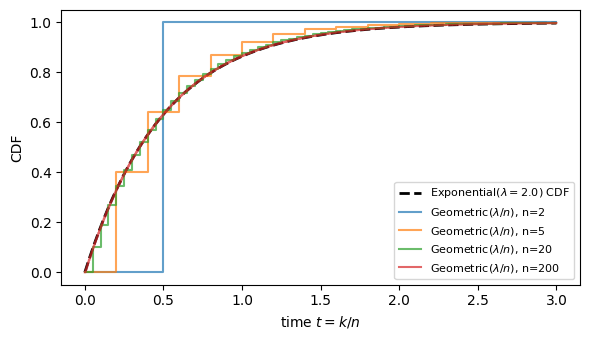

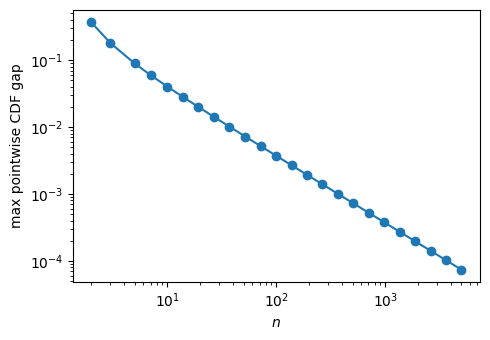

In [9]:
lam = 2.0
t = np.linspace(0, 3, 400)
exp_cdf = 1 - np.exp(-lam * t)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(t, exp_cdf, 'k--', lw=2, label=f'Exponential($\\lambda={lam}$) CDF')

for n in [2, 5, 20, 200]:
    p = lam / n
    k_vals = np.arange(0, int(3 * n) + 1)
    geo_cdf = 1 - (1 - p) ** k_vals
    ax.step(k_vals / n, geo_cdf, where='post', alpha=0.7, label=f'Geometric($\\lambda/n$), n={n}')

ax.set_xlabel('time $t = k/n$')
ax.set_ylabel('CDF')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# max pointwise CDF gap, shrinking as n grows
n_range = np.unique(np.geomspace(2, 5000, 25).astype(int))
max_gaps = []
for n in n_range:
    p = lam / n
    k_vals = np.arange(0, int(5 * n) + 1)
    geo_cdf = 1 - (1 - p) ** k_vals
    t_vals = k_vals / n
    exp_at_t = 1 - np.exp(-lam * t_vals)
    max_gaps.append(np.max(np.abs(geo_cdf - exp_at_t)))

fig2, ax2 = plt.subplots(figsize=(5, 3.5))
ax2.loglog(n_range, max_gaps, 'o-')
ax2.set_xlabel('$n$')
ax2.set_ylabel('max pointwise CDF gap')
plt.tight_layout()
plt.show()

## Example: continuous noise in randomized trace estimation

Recall Hutchinson's estimator from L4–L5: for $A\in\mathbb R^{n\times n}$, draw
$z\in\mathbb R^n$ with i.i.d.\ mean-$0$, variance-$1$, pairwise independent entries
and set $\tau = z^\top A z$. The unbiasedness proof only ever used
$$
E[z_i^2] = 1 \qquad\text{and}\qquad E[z_iz_j] = 0 \ (i\ne j),
$$
which followed from mean $0$, variance $1$, and pairwise independence —
**nothing about $z_i$ being discrete**. So a continuous $z_i$ works exactly as well.

::: {.callout-tip}
## A continuous alternative
Instead of Rademacher entries $z_i=\pm1$, draw $z_i$ i.i.d.\ from a continuous
distribution with mean $0$ and variance $1$ — for concreteness, the (bell-shaped)
standard Gaussian, whose PDF we'll meet formally in a later lecture. Same proof, same
unbiasedness, now with continuous noise.
:::

In [10]:
rng = np.random.default_rng(151)
d = 50
A = rng.standard_normal((d, d)) + 5 * np.eye(d)
true_trace = np.trace(A)

num_samples = 20_000
Z_rad = rng.choice([-1.0, 1.0], size=(num_samples, d))  # discrete: Rademacher
Z_gauss = rng.standard_normal((num_samples, d))          # continuous: standard Gaussian

tau_rad = np.einsum('si,ij,sj->s', Z_rad, A, Z_rad)
tau_gauss = np.einsum('si,ij,sj->s', Z_gauss, A, Z_gauss)

print(f"true trace(A)                        = {true_trace:.4f}")
print(f"mean of tau, Rademacher z (discrete)  = {tau_rad.mean():.4f}")
print(f"mean of tau, Gaussian z (continuous)  = {tau_gauss.mean():.4f}")

true trace(A)                        = 250.0783
mean of tau, Rademacher z (discrete)  = 249.9342
mean of tau, Gaussian z (continuous)  = 249.5031
